# DENSE VAE RESULTS

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

2026-06-24 16:24:08.567886: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-24 16:24:08.649277: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
DENSE_VAE_MODELS_DIR = "../models/dense_VAE"
MODEL_NAME = "dense_vae_0"
INPUT_DIM = 57
LATENT_DIM = 16
BETA = 0.01

ENCODER_PATH = os.path.join(DENSE_VAE_MODELS_DIR, f"{MODEL_NAME}_encoder.keras")
DECODER_PATH = os.path.join(DENSE_VAE_MODELS_DIR, f"{MODEL_NAME}_decoder.keras")

In [3]:
BACKGROUND_FILE = "../data/datasets/dense/background_dense_dataset.h5"

SIGNAL_FILES = {
    "Ato4l": "../data/datasets/dense/Ato4l_dense_dataset.h5",
    "hChToTauNu": "../data/datasets/dense/hChToTauNu_dense_dataset.h5",
    "hToTauTau": "../data/datasets/dense/hToTauTau_dense_dataset.h5",
    "leptoquark": "../data/datasets/dense/leptoquark_dense_dataset.h5",
}

with h5py.File(BACKGROUND_FILE, "r") as f:
    X_train = f["X_train"][:].astype(np.float32)
    X_val = f["X_val"][:].astype(np.float32)
    X_test = f["X_test"][:].astype(np.float32)

N_OBJ = 19
PT_COLS = [i * 3 for i in range(N_OBJ)]
W_CURR = {"pt": 1.0, "eta": 1.0, "phi": 0.5}
PT_STD = X_train[:, PT_COLS].std() + 1e-8

print(f"{'X_train':<10}: {X_train.shape}")
print(f"{'X_val':<10}: {X_val.shape}")
print(f"{'X_test':<10}: {X_test.shape}")

signals = {}
for name, path in SIGNAL_FILES.items():
    with h5py.File(path, "r") as f:
        key = list(f.keys())[0]
        signals[name] = f[key][:].astype(np.float32)
    print(f"{name:<10}: {signals[name].shape}")

X_train   : (8609225, 57)
X_val     : (2152307, 57)
X_test    : (2690383, 57)
Ato4l     : (55969, 57)
hChToTauNu: (760272, 57)
hToTauTau : (691283, 57)
leptoquark: (340544, 57)


In [4]:
try:
    register_keras_serializable = keras.saving.register_keras_serializable
except AttributeError:
    register_keras_serializable = keras.utils.register_keras_serializable

@register_keras_serializable(package="Custom")
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps


def build_encoder(input_dim=57, latent_dim=16):
    inp = keras.Input(shape=(input_dim,), name="encoder_input")
    x = layers.BatchNormalization()(inp)
    x = layers.Dense(48, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.Dense(32, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling(name="z")([z_mean, z_log_var])
    return keras.Model(inp, [z_mean, z_log_var, z], name="encoder")


def build_decoder(input_dim=57, latent_dim=16):
    latent_inputs = keras.Input(shape=(latent_dim,), name="decoder_input")
    x = layers.Dense(32, use_bias=False)(latent_inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.Dense(48, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    out = layers.Dense(input_dim, name="reconstruction")(x)
    return keras.Model(latent_inputs, out, name="decoder")


def reconstruction_event_loss(y_true, y_pred, pt_std, weights):
    y_true = tf.reshape(y_true, (-1, 19, 3))
    y_pred = tf.reshape(y_pred, (-1, 19, 3))

    mask = tf.cast(tf.not_equal(y_true[:, :, 0:1], 0.0), tf.float32)
    n_present = tf.maximum(tf.reduce_sum(mask, axis=[1, 2]), 1.0)

    pt_true = y_true[:, :, 0:1]
    pt_pred = y_pred[:, :, 0:1]
    pt_loss = tf.square(pt_true - pt_pred) / (pt_std ** 2)

    eta_true = y_true[:, :, 1:2]
    eta_pred = y_pred[:, :, 1:2]
    eta_loss = tf.square((eta_true - eta_pred) / 3.0)

    phi_true = y_true[:, :, 2:3]
    phi_pred = y_pred[:, :, 2:3]
    dphi = tf.atan2(tf.sin(phi_true - phi_pred), tf.cos(phi_true - phi_pred))
    phi_loss = tf.square(dphi)

    total = (
        weights["pt"] * pt_loss
        + weights["eta"] * eta_loss
        + weights["phi"] * phi_loss
    )
    total = total * mask

    return tf.reduce_sum(total, axis=[1, 2]) / n_present

custom_objects = {
    "Sampling": Sampling,
    "Custom>Sampling": Sampling,
}
encoder = keras.models.load_model(
    ENCODER_PATH,
    compile=False,
    custom_objects=custom_objects,
    safe_mode=False,
 )
decoder = keras.models.load_model(
    DECODER_PATH,
    compile=False,
    custom_objects=custom_objects,
    safe_mode=False,
 )

print(f"Loaded encoder: {ENCODER_PATH}")
print(f"Loaded decoder: {DECODER_PATH}")

I0000 00:00:1782311068.465867   44339 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13760 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:07.0, compute capability: 7.5


Loaded encoder: ../models/dense_VAE/dense_vae_0_encoder.keras
Loaded decoder: ../models/dense_VAE/dense_vae_0_decoder.keras


In [5]:
def compute_scores(X, batch_size=4096):
    X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
    z_mean, z_log_var, z = encoder(X_tf, training=False)
    X_rec = decoder(z, training=False)

    reco_evt = reconstruction_event_loss(X_tf, X_rec, pt_std=PT_STD, weights=W_CURR)
    kl_evt = -0.5 * tf.reduce_sum(
        1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
        axis=1,
    )
    elbo_evt = reco_evt + BETA * kl_evt

    return {
        "reco": reco_evt.numpy(),
        "kl": kl_evt.numpy(),
        "elbo": elbo_evt.numpy(),
    }

bkg_scores = compute_scores(X_test)
signal_scores = {name: compute_scores(arr) for name, arr in signals.items()}

print(
    f"Background ELBO: mean={bkg_scores['elbo'].mean():.6f}, std={bkg_scores['elbo'].std():.6f}"
)
for name, sc in signal_scores.items():
    print(f"{name:<10} ELBO: mean={sc['elbo'].mean():.6f}, std={sc['elbo'].std():.6f}")

Background ELBO: mean=0.232400, std=0.179346
Ato4l      ELBO: mean=0.955175, std=2.327461
hChToTauNu ELBO: mean=0.683693, std=1.327757
hToTauTau  ELBO: mean=0.462548, std=1.056147
leptoquark ELBO: mean=0.493723, std=0.490555


In [6]:
FPR_THRESHOLD = 1e-5
target_background = np.zeros(bkg_scores['elbo'].shape[0], dtype=np.float32)

rows = []
roc_curves = {}
for name, sc in signal_scores.items():
    y_true = np.concatenate([np.ones(sc['elbo'].shape[0], dtype=np.float32), target_background])
    y_pred = np.concatenate([sc['elbo'], bkg_scores['elbo']])

    fpr, tpr, thr = roc_curve(y_true, y_pred)
    auc_val = auc(fpr, tpr)

    idx = np.searchsorted(fpr, FPR_THRESHOLD, side="right") - 1
    idx = max(idx, 0)
    tpr_at_threshold = tpr[idx]

    roc_curves[name] = {
        "fpr": fpr,
        "tpr": tpr,
        "thr": thr,
        "auc": auc_val,
        "tpr_at_threshold": tpr_at_threshold,
    }

    rows.append({
        "Signal": name,
        "AUC [%]": 100.0 * auc_val,
        "TPR @ FPR=1e-5 [%]": 100.0 * tpr_at_threshold,
        "TPR @ FPR=1e-5 [# events]": f"{int(round(tpr_at_threshold * sc['elbo'].shape[0]))} / {sc['elbo'].shape[0]}"
    })

df_metrics = pd.DataFrame(rows).set_index("Signal")
display(df_metrics.style.format({"AUC [%]": "{:.2f}", "TPR @ FPR=1e-5 [%]": "{:.4f}"}))

,AUC [%],TPR @ FPR=1e-5 [%],TPR @ FPR=1e-5 [# events]
Signal,,,
Ato4l,89.19,0.4896,274 / 55969
hChToTauNu,90.28,0.0689,524 / 760272
hToTauTau,74.95,0.0346,239 / 691283
leptoquark,85.88,0.0176,60 / 340544


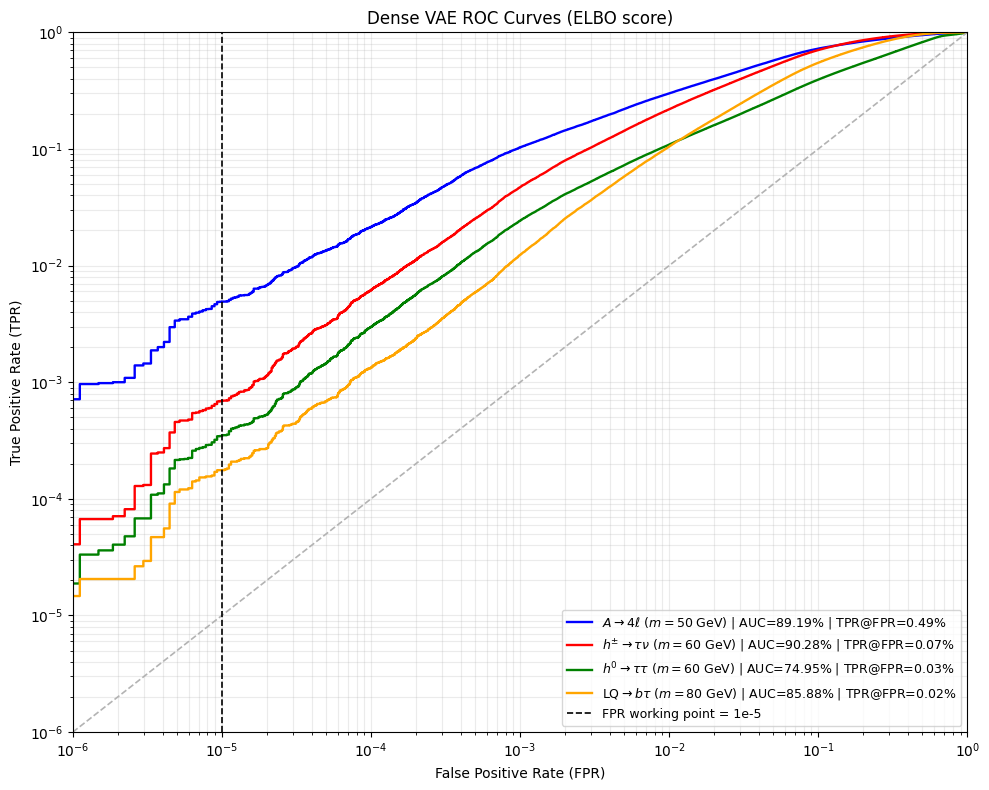

In [7]:
sample_colors = {
    "background": "black",
    "Ato4l": "blue",
    "hChToTauNu": "red",
    "hToTauTau": "green",
    "leptoquark": "orange",
}

signal_labels = {
    "Ato4l": r"$A \rightarrow 4\ell$ ($m = 50\text{ GeV}$)",
    "hChToTauNu": r"$h^{\pm} \rightarrow \tau \nu$ ($m = 60\text{ GeV}$)",
    "hToTauTau": r"$h^0 \rightarrow \tau \tau$ ($m = 60\text{ GeV}$)",
    "leptoquark": r"$\text{LQ} \rightarrow b \tau$ ($m = 80\text{ GeV}$)",
}

plt.figure(figsize=(10, 8))
for name in SIGNAL_FILES.keys():
    rc = roc_curves[name]
    plt.plot(
        rc['fpr'],
        rc['tpr'],
        linewidth=1.7,
        color=sample_colors[name],
        label=f"{signal_labels[name]} | AUC={rc['auc']*100:.2f}% | TPR@FPR={rc['tpr_at_threshold']*100:.2f}%"
    )

plt.plot([1e-6, 1.0], [1e-6, 1.0], "--", color="0.70", linewidth=1.2)
plt.axvline(FPR_THRESHOLD, color="black", linestyle="--", linewidth=1.2, label="FPR working point = 1e-5")
plt.xscale("log")
plt.yscale("log")
plt.xlim(1e-6, 1.0)
plt.ylim(1e-6, 1.0)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Dense VAE ROC Curves (ELBO score)")
plt.grid(True, which="both", alpha=0.25)
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

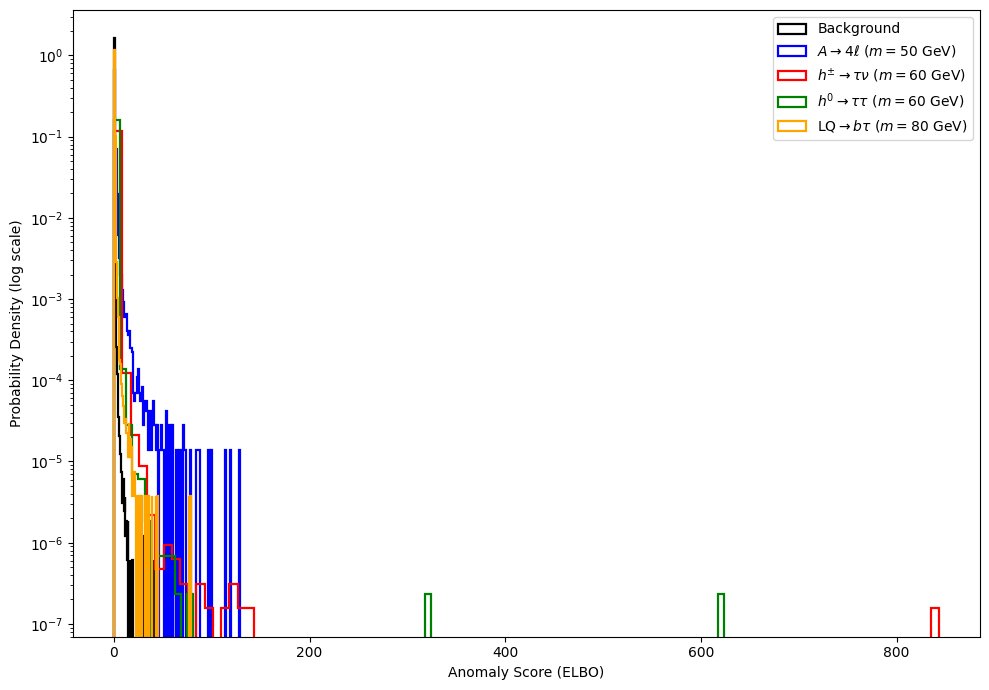

In [8]:
plt.figure(figsize=(10, 7))

plt.hist(
    bkg_scores['elbo'],
    bins=100,
    density=True,
    histtype="step",
    linewidth=1.6,
    label="Background",
    color=sample_colors['background'],
)

for name in SIGNAL_FILES.keys():
    plt.hist(
        signal_scores[name]['elbo'],
        bins=100,
        density=True,
        histtype="step",
        linewidth=1.6,
        label=signal_labels[name],
        color=sample_colors[name],
    )

plt.yscale("log")
plt.xlabel("Anomaly Score (ELBO)")
plt.ylabel("Probability Density (log scale)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [9]:
out_dir = Path("../results/dense_VAE") / MODEL_NAME
out_dir.mkdir(parents=True, exist_ok=True)
PNG_DPI = 300

# Save score distributions
fig_scores = plt.figure(figsize=(10, 7))
plt.hist(
    bkg_scores['elbo'],
    bins=100,
    density=True,
    histtype="step",
    linewidth=1.6,
    label="Background",
    color=sample_colors['background'],
)
for name in SIGNAL_FILES.keys():
    plt.hist(
        signal_scores[name]['elbo'],
        bins=100,
        density=True,
        histtype="step",
        linewidth=1.6,
        label=name,
        color=sample_colors[name],
    )
plt.yscale("log")
plt.xlabel("Anomaly Score (ELBO)")
plt.ylabel("Probability Density (log scale)")
plt.legend(loc="upper right")
plt.tight_layout()
fig_scores.savefig(out_dir / "scores_elbo.png", dpi=PNG_DPI, bbox_inches="tight")
plt.close(fig_scores)

# Save ROC plot
fig_roc = plt.figure(figsize=(10, 8))
for name in SIGNAL_FILES.keys():
    rc = roc_curves[name]
    plt.plot(rc['fpr'], rc['tpr'], linewidth=1.7, color=sample_colors[name], label=f"{signal_labels[name]} | AUC={rc['auc']*100:.2f}% | TPR@FPR={rc['tpr_at_threshold']*100:.2f}%")
plt.plot([1e-6, 1.0], [1e-6, 1.0], "--", color="0.70", linewidth=1.2)
plt.axvline(FPR_THRESHOLD, color="blue", linestyle="--", linewidth=1.2, label="FPR working point = 1e-5")
plt.xscale("log")
plt.yscale("log")
plt.xlim(1e-6, 1.0)
plt.ylim(1e-6, 1.0)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Dense VAE ROC Curves (ELBO score)")
plt.grid(True, which="both", alpha=0.25)
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
fig_roc.savefig(out_dir / "roc_elbo.png", dpi=PNG_DPI, bbox_inches="tight")
plt.close(fig_roc)

# Save numeric artifacts
scores_payload = {
    "bkg_reco": bkg_scores['reco'].astype(np.float32),
    "bkg_kl": bkg_scores['kl'].astype(np.float32),
    "bkg_elbo": bkg_scores['elbo'].astype(np.float32),
}
for name in SIGNAL_FILES.keys():
    scores_payload[f"{name}_reco"] = signal_scores[name]['reco'].astype(np.float32)
    scores_payload[f"{name}_kl"] = signal_scores[name]['kl'].astype(np.float32)
    scores_payload[f"{name}_elbo"] = signal_scores[name]['elbo'].astype(np.float32)
np.savez_compressed(out_dir / "scores.npz", **scores_payload)

roc_payload = {}
for name in SIGNAL_FILES.keys():
    rc = roc_curves[name]
    roc_payload[f"fpr_{name}"] = rc['fpr'].astype(np.float32)
    roc_payload[f"tpr_{name}"] = rc['tpr'].astype(np.float32)
    roc_payload[f"thr_{name}"] = rc['thr'].astype(np.float32)
    roc_payload[f"auc_{name}"] = np.array([rc['auc']], dtype=np.float64)
    roc_payload[f"tpr_at_fpr_1e5_{name}"] = np.array([rc['tpr_at_threshold']], dtype=np.float64)
np.savez_compressed(out_dir / "roc_data.npz", **roc_payload)

df_metrics.to_csv(out_dir / "metrics.csv")

print(f"Export completed: {out_dir}")
print("Saved files:")
for name in ["metrics.csv", "roc_elbo.png", "scores_elbo.png", "roc_data.npz", "scores.npz"]:
    print(" -", name)

Export completed: ../results/dense_VAE/dense_vae_0
Saved files:
 - metrics.csv
 - roc_elbo.png
 - scores_elbo.png
 - roc_data.npz
 - scores.npz
